In [1]:
#logistic regression
import kagglehub

import os

import pandas as pd

# 1. Download the dataset

# This defines 'path' in the current environment

path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

# 2. List and Load

# Now 'os' and 'path' are both defined

files = os.listdir(path)

print(f"Files found: {files}")

# The Kaggle Iris dataset usually contains 'Iris.csv'

csv_file = [f for f in files if f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, csv_file))

C:\Users\Pooja\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Pooja\.cache\kagglehub\datasets\uciml\iris\versions\2
Files found: ['database.sqlite', 'Iris.csv']


In [2]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


In [5]:
df.isnull().sum

<bound method DataFrame.sum of         Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0    False          False         False          False         False    False
1    False          False         False          False         False    False
2    False          False         False          False         False    False
3    False          False         False          False         False    False
4    False          False         False          False         False    False
..     ...            ...           ...            ...           ...      ...
145  False          False         False          False         False    False
146  False          False         False          False         False    False
147  False          False         False          False         False    False
148  False          False         False          False         False    False
149  False          False         False          False         False    False

[150 rows x 6 columns]>

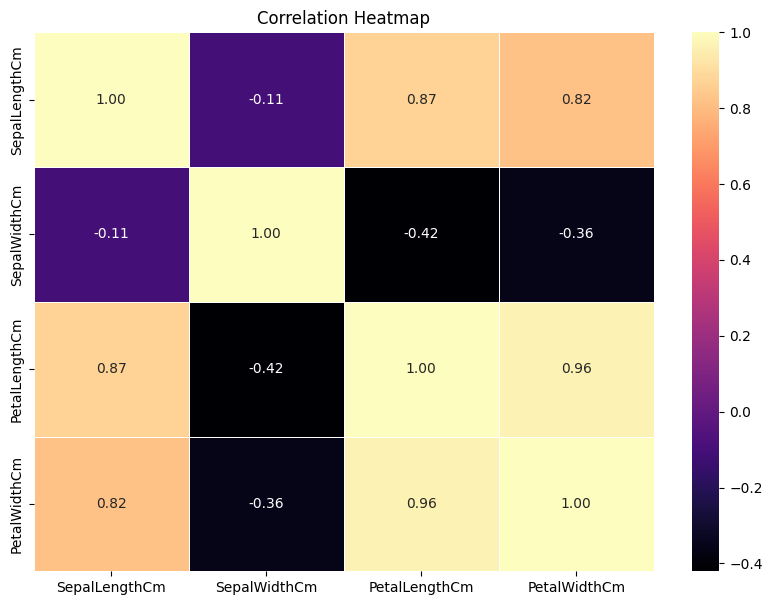

In [6]:
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()

X = df[['SepalLengthCm',  'SepalWidthCm', 'PetalLengthCm',  'PetalWidthCm']]

Y = df['Id']

corr = X.corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap='magma', fmt='.2f', linewidth=0.5)

plt.title('Correlation Heatmap')

plt.show()

In [7]:
df.shape

(150, 6)

In [8]:
X=df.drop(columns = ['Id','Species'])
Y = df['Species']

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y)

mapping = dict(zip(encoder.classes_,encoder.transform(encoder.classes_)))
print('Species Mapping :',mapping)

Species Mapping : {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y_encoded,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
#initialize the model
model = LogisticRegression()
#fit the model
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
#calculate (after the model selection check how well the machine performs using the test dataset)
#for that use of metrics
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(Y_test, Y_pred, target_names=encoder.classes_))
print(confusion_matrix(Y_test, Y_pred))

Accuracy: 1.00
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


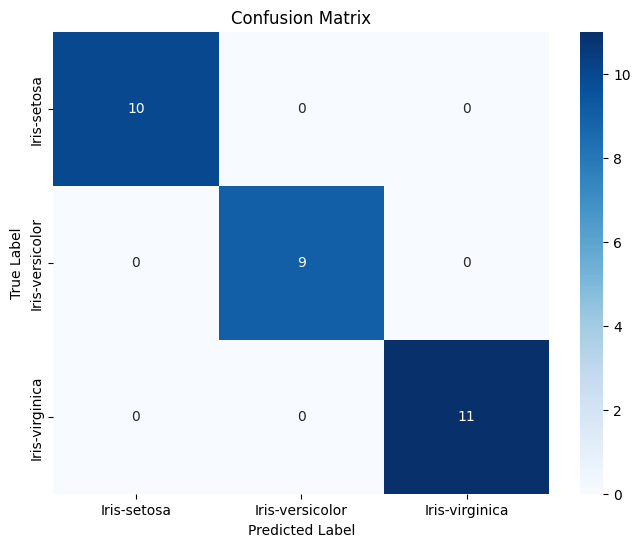

In [15]:
#visualization
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',

            xticklabels=encoder.classes_,

            yticklabels=encoder.classes_)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

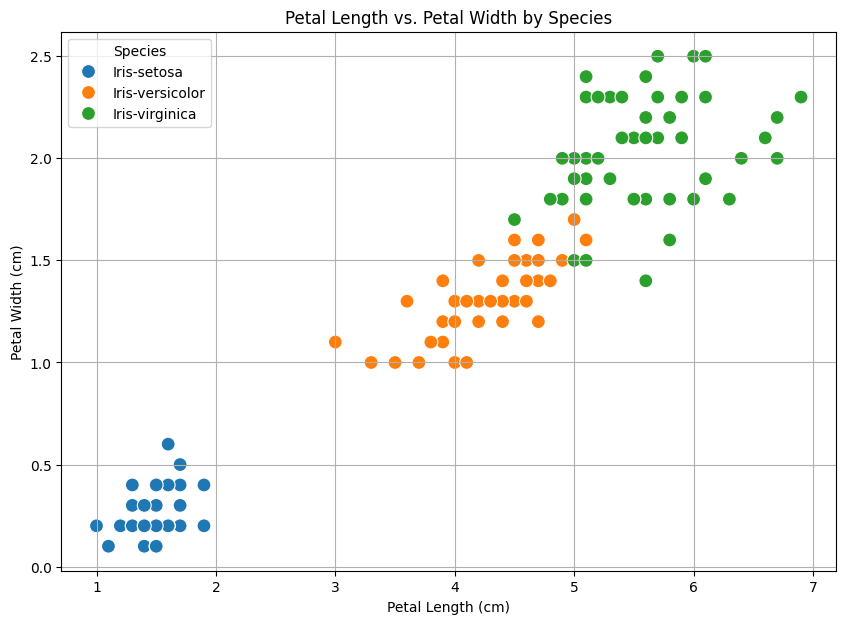

In [16]:
#visulaization

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Species', data=df, s=100)
plt.title('Petal Length vs. Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True)
plt.legend(title='Species')
plt.show()